## Data Insights

Findings:
1. A larger science sector does not necessarily produce more psychology research
2. 

This notebook loads `data/processed/publication_data.csv`, produced by `00_data_processing.ipynb`.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import statsmodels.api as sm
from IPython.display import HTML
from scipy import stats

### Figure guidelines

In [2]:
SERIF, SANS, BG = "Libre Baskerville", "Libre Franklin", "#F7F7F7"
RED, GREEN, GRAY = "#7A1E1A", "#236534", "#C9BFBA"

HOVER = dict(bgcolor="white", 
             bordercolor="rgba(0, 0, 0, 0.1)",
             font=dict(family=SANS, size=12, color="black"))

AXIS_DEFAULTS = dict(gridcolor="white", linecolor="white", ticks="", zerolinecolor="white",
                     zerolinewidth=2, automargin=True, title=dict(standoff=15))

SITE_TEMPLATE = dict(layout=dict(
    autotypenumbers="strict", hovermode="closest", font=dict(color="#2a3f5f"),
    hoverlabel=dict(align="left"), paper_bgcolor="white", plot_bgcolor="#E5ECF6",
    geo=dict(subunitcolor="white", showland=True, showlakes=True, lakecolor="white"),
    xaxis=AXIS_DEFAULTS, yaxis=AXIS_DEFAULTS,
))

def titled(fig, title, subtitle, legend=None, png=None, height=600, margin=None):
    """
    Add title/subtitle/legend back onto bare site figures, for display and figures/PNGs.
    
    """
    out = go.Figure(fig).update_layout(
        width=800, height=height, autosize=False, margin=margin,
        title=dict(
            x=0.5, font=dict(family=SERIF, size=18, color="black"),
            text=f"{title}<br><span style='font-family:{SANS};font-size:13px'>{subtitle}</span>",
        ),
    )
    if legend:
        out.add_annotation(
            x=0.5, y=1.02, xref="paper", yref="paper", xanchor="center", showarrow=False,
            font=dict(family=SANS, size=12, color="black"),
            text="&nbsp;&nbsp;&nbsp;&nbsp;".join(
                f"<span style='color:{color}'>●</span> {label}" for label, color in legend),
        )
    if png:
        out.write_image(f"../figures/{png}")
    return out

def write_chart_data(charts, path="../docs/chart-data.js"):
    """
    Produces script with plotly specs (../docs/js/chats-data.js).

    """
    blocks = []
    for chart_id, fig in charts.items():
        spec = json.loads(fig.to_json())
        spec["layout"]["template"] = SITE_TEMPLATE
        traces = ",\n  ".join(json.dumps(trace) for trace in spec["data"])
        blocks.append(f'{{"id": "{chart_id}",\n "data": [\n  {traces}\n ],\n'
                      f' "layout": {json.dumps(spec["layout"], indent=2)}}}')
    Path(path).write_text(
        "/* Generated by notebooks/01_data_insights.ipynb.\n"
        "   Plotly specs for the three figures in index.html. */\n"
        "window.CHART_SPECS = [\n" + ",\n".join(blocks) + "\n];\n")
    print(f"wrote {path} ({Path(path).stat().st_size:,} bytes)")

def short_number(number):
    """
    Returns str: the short-form (K or M) of a long-form number (ex. 1000 becomes 1K).
     
    """

    for cutoff, suffix in ((1_000_000, "M"), (1_000, "K")):
        if abs(number) >= cutoff:
            scaled = number / cutoff
            return f"{int(scaled)}{suffix}" if scaled == int(scaled) else f"{round(scaled, 1)}{suffix}"
    return str(number)

def gradient_color(value, scale, low, high):
    """
    Get hex color for value in gradient
    """
    position = min(max((value - low) / (high - low), 0), 1) if high > low else 0.5
    index = min(int(position * (len(scale) - 1)), len(scale) - 2)
    fraction = position * (len(scale) - 1) - index
    start, end = (tuple(int(c[i:i + 2], 16) for i in (1, 3, 5)) for c in scale[index:index + 2])
    return "#%02x%02x%02x" % tuple(int(a + (b - a) * fraction) for a, b in zip(start, end))

In [3]:
merged_data = pd.read_csv("../data/processed/publication_data.csv")

wdi_cols = [c for c in merged_data.columns if c not in
            ['iso_alpha', 'Year', 'Publications', 'Country', 'data_source_flag']]
years_with_wdi = merged_data.loc[merged_data[wdi_cols].notna().any(axis=1), 'Year']

print(f"Country-year rows: {len(merged_data)}")
print(f"Distinct countries: {merged_data['Country'].nunique()}")
print(f"Years: {merged_data['Year'].min()}-{merged_data['Year'].max()}")
print(f"Years with WDI coverage: {years_with_wdi.min()}-{years_with_wdi.max()} ({years_with_wdi.nunique()} years)")

Country-year rows: 4020
Distinct countries: 201
Years: 2003-2022
Years with WDI coverage: 2003-2022 (20 years)


Window: 2011 - 2022.

In [47]:
mean_cols = [
    'GDP_per_capita', 'GDP_per_capita_PPP', 'GNI_per_capita_PPP', 'Population',
    'Tertiary_enrollment_pct', 'RnD_expenditure_pct', 'Researchers_per_million',
    'Education_expenditure_pct', 'Tertiary_education_expenditure_pct',
    'Urban_population_pct', 'Sci_tech_articles', 'Internet_users_pct',
]

country_summary = merged_data.groupby(['iso_alpha', 'Country'], as_index=False).agg(
    Publications=('Publications', lambda x: x.sum(min_count=1)),
    SE_articles_total=('SE_articles_total', lambda x: x.sum(min_count=1)),
    n_years=('Year', 'nunique'),
    data_source_flag=('data_source_flag', 'first'),
    **{col: (col, 'mean') for col in mean_cols},
)

country_summary['psych_share'] = country_summary['Publications'] / country_summary['SE_articles_total']
country_summary['log_publications'] = np.log1p(country_summary['Publications'])

print(f"Countries: {len(country_summary)}")
print(f"Years: {merged_data['Year'].min()}-{merged_data['Year'].max()}")
print(f"Total psychology publications: {country_summary['Publications'].sum():,.0f}")
print(f"Years covered per country: {country_summary['n_years'].min()}-{country_summary['n_years'].max()} "
      f"(median {country_summary['n_years'].median():.0f})")
print(f"Zero publications: {(country_summary['Publications'] == 0).sum()}")
print(f"Missing publications entirely: {country_summary['Publications'].isna().sum()}")
print(f"Missing GDP_per_capita: {country_summary['GDP_per_capita'].isna().sum()}")

Countries: 201
Years: 2003-2022
Total psychology publications: 815,406
Years covered per country: 20-20 (median 20)
Zero publications: 10
Missing publications entirely: 0
Missing GDP_per_capita: 4


In [37]:
window = merged_data[merged_data['Year'].between(2011, 2022)]

country_summary_11_22 = window.groupby(['iso_alpha', 'Country'], as_index=False).agg(
    Publications=('Publications', lambda x: x.sum(min_count=1)),
    SE_articles_total=('SE_articles_total', lambda x: x.sum(min_count=1)),
    n_years=('Year', 'nunique'),
    data_source_flag=('data_source_flag', 'first'),
    **{col: (col, 'mean') for col in mean_cols},
)

country_summary_11_22['psych_share'] = (
    country_summary_11_22['Publications'] / country_summary_11_22['SE_articles_total'])
country_summary_11_22['log_publications'] = np.log1p(country_summary_11_22['Publications'])

print(f"Countries in 2011-2022 summary: {len(country_summary_11_22)}")
print(f"Total psychology publications (2011-2022): {country_summary_11_22['Publications'].sum():,.0f}")
print(f"Zero publications: {(country_summary_11_22['Publications'] == 0).sum()}")

Countries in 2011-2022 summary: 201
Total psychology publications (2011-2022): 596,911
Zero publications: 12


### Global distribution, mapped

In [38]:
nonzero = country_summary_11_22['Publications'] > 0
q1, q2, q3 = country_summary_11_22.loc[nonzero, 'Publications'].quantile([0.25, 0.5, 0.75])
median = country_summary_11_22['Publications'].median()
plot_min = country_summary_11_22['Publications'].min()
plot_max = country_summary_11_22['Publications'].max()

print(f"zero contributions share: {(~nonzero).mean():.2%}")
print(f"min: {plot_min}, q1: {q1}, median (all): {median}, q2 (nonzero): {q2}, q3: {q3}, max: {plot_max}")

country_summary_11_22['quartile'] = 'Zero publications'
country_summary_11_22.loc[nonzero, 'quartile'] = pd.qcut(
    country_summary_11_22.loc[nonzero, 'Publications'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4']
)

print(country_summary_11_22['quartile'].value_counts())

top_quartile = country_summary_11_22.sort_values('Publications', ascending=False)
bottom_quartile = country_summary_11_22[country_summary_11_22['Publications'] > 0].sort_values('Publications')

print(f"\nTop 5 contributors:\n{top_quartile.iloc[:5, :3]}")
print(f"\nBottom 5 contributors, non-zero:\n{bottom_quartile.iloc[:5, :3]}")

top_5 = top_quartile.iloc[:5].set_index('iso_alpha')['Country'].to_dict()

zero contributions share: 5.97%
min: 0.0, q1: 6.17, median (all): 34.99, q2 (nonzero): 45.41, q3: 700.51, max: 201664.58000000002
quartile
Q1                   48
Q2                   47
Q3                   47
Q4                   47
Zero publications    12
Name: count, dtype: int64

Top 5 contributors:
    iso_alpha         Country  Publications
188       USA   United States     201664.58
62        GBR  United Kingdom      49574.46
45        DEU         Germany      38102.80
29        CAN          Canada      29663.27
32        CHN           China      27903.16

Bottom 5 contributors, non-zero:
    iso_alpha       Country  Publications
182       TUV        Tuvalu          0.05
112       MDV      Maldives          0.10
39        COM       Comoros          0.20
37        COK  Cook Islands          0.22
194       VUT       Vanuatu          0.40


### Psychology-specific

In [39]:
world_total_psych = country_summary_11_22['Publications'].sum()
us = country_summary_11_22.loc[country_summary_11_22['Country'] == 'United States', 'Publications'].values[0]
print(f"world total: {world_total_psych:,.0f}")
print(f"US share: {us / world_total_psych:.1%}")

world_pop = country_summary_11_22['Population'].sum()
us_pop = country_summary_11_22.loc[country_summary_11_22['Country'] == 'United States', 'Population'].values[0]
print(f"US share of population: {us_pop / world_pop:.1%}\n")

non_us = country_summary_11_22[country_summary_11_22['Country'] != 'United States'].sort_values('Publications', ascending=False)

for rank, (_, row) in enumerate(non_us[:4].iterrows(), start=2):
    ratio = us / row['Publications']
    pop_share = row['Population'] / world_pop
    pub_share = row['Publications'] / world_total_psych
    print(f"US is {ratio:.1f}x {row['Country']} (#{rank}), who has {pub_share:.1%} of world publications "
          f"and {pop_share:.1%} of world population")

top_5_psych = us + top_quartile[1:5]['Publications'].sum()
print(f"\ntop 5 combined: {top_5_psych / world_total_psych:.1%} of world publications")

world total: 596,911
US share: 33.8%
US share of population: 4.3%

US is 4.1x United Kingdom (#2), who has 8.3% of world publications and 0.9% of world population
US is 5.3x Germany (#3), who has 6.4% of world publications and 1.1% of world population
US is 6.8x Canada (#4), who has 5.0% of world publications and 0.5% of world population
US is 7.2x China (#5), who has 4.7% of world publications and 18.4% of world population

top 5 combined: 58.1% of world publications


### All subjects

In [52]:
top_quartile_all_SE = country_summary.sort_values('SE_articles_total', ascending=False)

print(f"\nTop 5 contributors, all SE subjects:\n{top_quartile_all_SE[:5].loc[:, ['Country','SE_articles_total']]}")

top_5_SE_all_subjects = top_quartile_all_SE.iloc[:5].set_index('iso_alpha')['Country'].to_dict()


Top 5 contributors, all SE subjects:
            Country  SE_articles_total
188   United States         8419082.31
32            China         7818687.13
88            Japan         2129293.46
45          Germany         2024561.42
62   United Kingdom         1936100.46


In [40]:
top_quartile_all_SE = country_summary_11_22.sort_values('SE_articles_total', ascending=False)

print(f"\nTop 5 contributors, all SE subjects:\n{top_quartile_all_SE[:5].loc[:, ['Country','SE_articles_total']]}")

top_5_SE_all_subjects = top_quartile_all_SE.iloc[:5].set_index('iso_alpha')['Country'].to_dict()


Top 5 contributors, all SE subjects:
           Country  SE_articles_total
32           China         6192884.71
188  United States         5324328.63
79           India         1442145.44
45         Germany         1322304.22
88           Japan         1263777.51


In [41]:
world_total_all = country_summary_11_22['SE_articles_total'].sum()
cn = country_summary_11_22.loc[country_summary_11_22['Country'] == 'China', 'SE_articles_total'].values[0]
print(f"world total: {world_total_all:,.0f}")

non_cn = country_summary_11_22[country_summary_11_22['Country'] != 'China'].sort_values('SE_articles_total', ascending=False)

for rank, (_, row) in enumerate(non_cn[:4].iterrows(), start=2):
    ratio = cn / row['SE_articles_total']
    pop_share = row['Population'] / world_pop
    pub_share = row['SE_articles_total'] / world_total_all
    print(f"China is {ratio:.1f}x {row['Country']} (#{rank}), who has {pub_share:.1%} of all world publications "
          f"and {pop_share:.1%} of world population")

top_5_total = cn + top_quartile_all_SE[1:5]['SE_articles_total'].sum()
print(f"\ntop 5 combined: {top_5_total / world_total_all:.1%} of all world publications")

world total: 30,603,567
China is 1.2x United States (#2), who has 17.4% of all world publications and 4.3% of world population
China is 4.3x India (#3), who has 4.7% of all world publications and 17.9% of world population
China is 4.7x Germany (#4), who has 4.3% of all world publications and 1.1% of world population
China is 4.9x Japan (#5), who has 4.1% of all world publications and 1.7% of world population

top 5 combined: 50.8% of all world publications


In [ ]:
red_scale = ["#F4E8D8", "#D6A89A", "#A3473F", "#7A1E1A"]
low, high = country_summary_11_22['log_publications'].min(), country_summary_11_22['log_publications'].max()

country_summary_11_22['hover_color'] = country_summary_11_22['log_publications'].map(
    lambda x: gradient_color(x, red_scale, low, high))
country_summary_11_22['pub_share_world'] = (country_summary_11_22['Publications'] / world_total_psych).round(6)
country_summary_11_22['pop_share_world'] = (country_summary_11_22['Population'] / world_pop).round(6)

pub_ticks = [0, 10, 100, 1000, 10000, 100000]

map_fig = go.Figure(go.Choropleth(
    locations=country_summary_11_22['iso_alpha'].tolist(),
    locationmode='ISO-3',
    z=country_summary_11_22['log_publications'].round(4).tolist(),
    colorscale=red_scale,
    customdata=country_summary_11_22[['Country', 'Publications', 'hover_color',
                                'pub_share_world', 'pop_share_world']].values.tolist(),
    hovertemplate="<b>%{customdata[0]} </b>"
                  "<span style='color:%{customdata[2]};vertical-align:middle'>■</span><br>"
                  "%{customdata[1]:,} publications<br>"
                  "%{customdata[3]:.1%} of world publications<br>"
                  "%{customdata[4]:.1%} of world population<extra></extra>",
    colorbar=dict(
        orientation='h', x=0.5, y=-0.12, xanchor='center', yanchor='middle',
        len=0.4, thickness=15, outlinewidth=0, ticks="",
        tickvals=[round(float(np.log1p(v)), 4) for v in pub_ticks],
        ticktext=[short_number(v) for v in pub_ticks],
        tickfont=dict(family=SANS, size=9, color="black"),
        title=dict(text="<b>Publications (Log Scale)</b>", side="top",
                   font=dict(family=SANS, size=12, color="black")),
    ),
))

map_fig.update_geos(showcountries=True, countrycolor="lightgray", countrywidth=0.5,
                    landcolor="#DAD7D7", showframe=False, bgcolor=BG, fitbounds="locations")

map_fig.update_layout(
    autosize=True, paper_bgcolor=BG, margin=dict(t=0, b=80, l=10, r=10, autoexpand=False),
    hoverlabel=HOVER,
)

titled(map_fig,
       "The US produced the largest share of global psychology publications",
       "Scopus Psychology Publications by Country (2011-2022), Fractional Contributions",
       png="main_map.png", height=500, margin=dict(t=100, b=80, l=10, r=10))

### Change over time

In [10]:
panel_cy = merged_data.groupby(['iso_alpha', 'Year'], as_index=False)['Publications'].sum()

world_by_year = panel_cy.groupby('Year')['Publications'].sum()
panel_cy = panel_cy.merge(world_by_year.rename('world_total'), left_on='Year', right_index=True)
panel_cy['share_of_world'] = panel_cy['Publications'] / panel_cy['world_total']

trend_countries = {"USA":"United States", "GBR":"United Kingdom", "CAN":"Canada", "DEU":"Germany", "CHN":"China"}
trend_colors = {"United States": RED, 
                "China": GREEN, 
                "United Kingdom": "#8C9BA5",
                "Canada": "#B5A08C", 
                "Germany": "#6B5744"}
legend_order = ["United States", "China", "United Kingdom", "Canada", "Germany"]

trend_fig = go.Figure()

for iso, name in trend_countries.items():
    sub = panel_cy[panel_cy['iso_alpha'] == iso].sort_values('Year')
    trend_fig.add_trace(go.Scatter(
        x=sub['Year'].tolist(), y=(sub['share_of_world'] * 100).round(4).tolist(),
        mode="lines+markers", name=name, showlegend=False,
        line=dict(color=trend_colors[name], width=3),
        marker=dict(size=6, color=trend_colors[name]),
        hovertemplate=f"<b>{name}</b><br>Year: %{{x}}<br>Share: %{{y:.2f}}%<extra></extra>",
    ))

trend_fig.update_xaxes(title="<b>Year</b>", showgrid=False, zeroline=False, automargin=False,
                       tickfont=dict(family=SANS, size=12))
trend_fig.update_yaxes(title="<b>Share of world psychology publications (%)</b>", showgrid=True,
                       gridcolor="#E5E5E5", zeroline=False, automargin=False,
                       tickfont=dict(family=SANS, size=12))

trend_fig.update_layout(
    autosize=True, paper_bgcolor=BG, plot_bgcolor=BG,
    font=dict(family=SANS, size=12, color="black"),
    hoverlabel=HOVER,
    margin=dict(t=20, b=70, l=90, r=20),
)

titled(trend_fig,
       "US psychology share fell as China overtook the UK, Canada, and Germany",
       "Five largest contributors by total output (2003-2022), as a share of world publications",
       legend=[(name, trend_colors[name]) for name in legend_order],
       png="global_share_overtime.png", margin=dict(t=120, b=70, l=90, r=40))


### Do psychology publications scale with the size of a country's overall science output?

In [48]:
rho = country_summary[['psych_share', 'SE_articles_total']].corr(method='spearman').loc['psych_share', 'SE_articles_total']
print(f"Spearman rho = {rho:.3f}")

Spearman rho = 0.217


In [51]:
top = (
    country_summary
    .dropna(subset=['SE_articles_total', 'psych_share'])
    .nlargest(15, 'SE_articles_total')
    .copy()
)

top['rank_volume'] = top['SE_articles_total'].rank(ascending=False)
top['rank_share'] = top['psych_share'].rank(ascending=False)
top['shift'] = top['rank_volume'] - top['rank_share']

rank_fig = go.Figure()

for _, r in top.iterrows():
    moved = abs(r['shift']) > 3
    color = RED if r['shift'] < -3 else GREEN if r['shift'] > 3 else GRAY

    rank_fig.add_trace(go.Scatter(
        x=[0, 1], y=[r['rank_volume'], r['rank_share']],
        mode="lines+markers", showlegend=False, opacity=1.0 if moved else 0.45,
        line=dict(color=color, width=3 if moved else 1.5),
        marker=dict(size=9, color=color, line=dict(width=0.6, color="white")),
        hovertemplate=(
            f"<b>{r['Country']}</b><br>"
            f"#{int(r['rank_volume'])} in total science output<br>"
            f"#{int(r['rank_share'])} by psychology's share of national science output"
            "<extra></extra>"
        ),
    ))

    for x, y, anchor in ((-0.08, r['rank_volume'], "right"), (1.08, r['rank_share'], "left")):
        rank_fig.add_annotation(x=x, y=y, text=r['Country'], xanchor=anchor, showarrow=False,
                                font=dict(family=SANS, size=12, color=color))

rank_fig.update_xaxes(
    range=[-0.35, 1.35], showgrid=False, zeroline=False, tickvals=[0, 1], tickangle=0,
    ticktext=["<b>Total S&E<br>publication output</b>", "<b>Psychology, % of<br>national S&E output</b>"],
    tickfont=dict(family=SANS, size=14),
)
rank_fig.update_yaxes(autorange="reversed", showgrid=False, zeroline=False, showticklabels=False)

rank_fig.update_layout(
    autosize=True, paper_bgcolor=BG, plot_bgcolor=BG,
    font=dict(family=SANS, size=12, color="black"),
    hoverlabel=HOVER,
    margin=dict(t=15, b=50, l=80, r=80, autoexpand=False),
)

titled(rank_fig,
       "A large science sector doesn't necessarily devote a larger share to psychology",
       "Top 15 countries by total science output (2003-2022), reranked by psychology's share of national science output",
       legend=[("Fell >3 ranks", RED), ("Rose >3 ranks", GREEN), ("Shift of 3 or fewer", GRAY)],
       png="rank_shift.png", height=750, margin=dict(t=130, b=60, l=110, r=110))

### Predictors

In [55]:
base = country_summary.dropna(subset=['SE_articles_total']).copy()
print(base[['Publications', 'SE_articles_total', 'psych_share']].describe().round(4).to_string())

       Publications  SE_articles_total  psych_share
count      201.0000       2.010000e+02     201.0000
mean      4056.7460       2.162312e+05       0.0141
std      22347.5618       8.697918e+05       0.0202
min          0.0000       4.660000e+00       0.0000
25%          6.1900       6.330000e+02       0.0048
50%         39.8400       5.341240e+03       0.0101
75%        594.9700       8.165708e+04       0.0179
max     296045.2000       8.419082e+06       0.2260


In [60]:
# Funnel diagnostic

base['granularity'] = 1 / base['SE_articles_total']
base['den_decile'] = pd.qcut(base['SE_articles_total'], 10, labels=False)

spread = base.groupby('den_decile').agg(
    n=('psych_share', 'size'),
    den_max=('SE_articles_total', 'max'),
    granularity=('granularity', 'median'),
    share_sd=('psych_share', 'std'),
    share_iqr=('psych_share', lambda x: x.quantile(.75) - x.quantile(.25)),
).round(5)

spread['granularity_ratio'] = spread['granularity'] / spread['share_sd']

print(spread.to_string())

             n     den_max  granularity  share_sd  share_iqr  granularity_ratio
den_decile                                                                     
0           21      146.03      0.01760   0.05233    0.01078           0.336327
1           20      307.59      0.00451   0.02286    0.01586           0.197288
2           20     1109.49      0.00156   0.00779    0.00731           0.200257
3           20     2260.62      0.00059   0.00834    0.01076           0.070743
4           20     5341.24      0.00029   0.00683    0.00899           0.042460
5           20    13143.45      0.00010   0.00924    0.01624           0.010823
6           20    44374.84      0.00004   0.00776    0.00648           0.005155
7           20   160320.78      0.00001   0.01009    0.01404           0.000991
8           20   385289.99      0.00000   0.01161    0.01658           0.000000
9           20  8419082.31      0.00000   0.01298    0.01945           0.000000


In [62]:
THRESHOLD = 1500
country_summary_noise_cutoff = base[(base['SE_articles_total'] >= THRESHOLD) &
         (base['Publications'] > 0)]
print(f"n = {len(country_summary_noise_cutoff)}")

n = 132


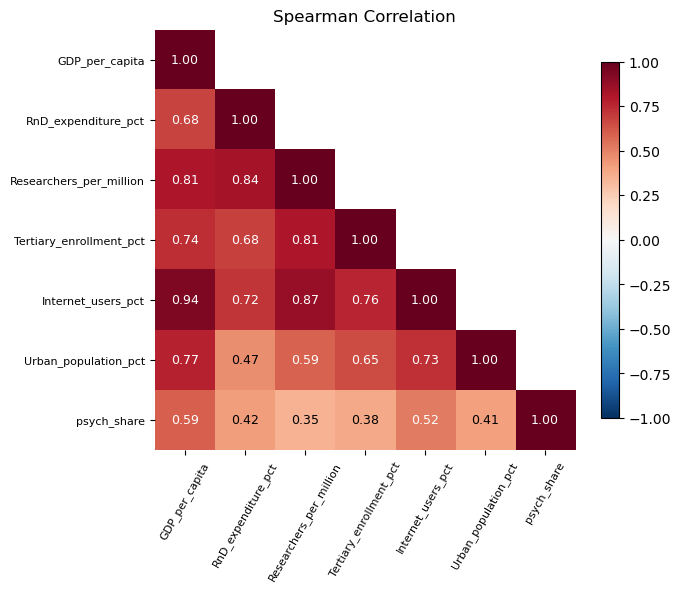

In [67]:
preds = ['GDP_per_capita', 
         'RnD_expenditure_pct',
         'Researchers_per_million', 
         'Tertiary_enrollment_pct',
         'Internet_users_pct', 
         'Urban_population_pct',
         'psych_share']

sub = country_summary_noise_cutoff[preds].dropna()
spear = sub.corr(method='spearman')
spear_masked = spear.where(np.tril(np.ones(spear.shape)).astype(bool))

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(spear_masked, cmap='RdBu_r', vmin=-1, vmax=1, origin='upper')

ax.set_xticks(range(len(spear)))
ax.set_xticklabels(spear.columns, rotation=60, fontsize=8)
ax.set_yticks(range(len(spear)))
ax.set_yticklabels(spear.columns, fontsize=8)
ax.set_title('Spearman Correlation')

for spine in ax.spines.values():
    spine.set_visible(False)

for i in range(len(spear)):
    for j in range(len(spear)):
        val = spear_masked.iloc[i, j]
        if pd.notna(val):
            val = float(val) # type: ignore
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9,
                    color="white" if abs(val) > 0.5 else "black")

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()

1,173 of 4,020 country-year observations are zero (29.2%), 100 of which have no GDP per capita data


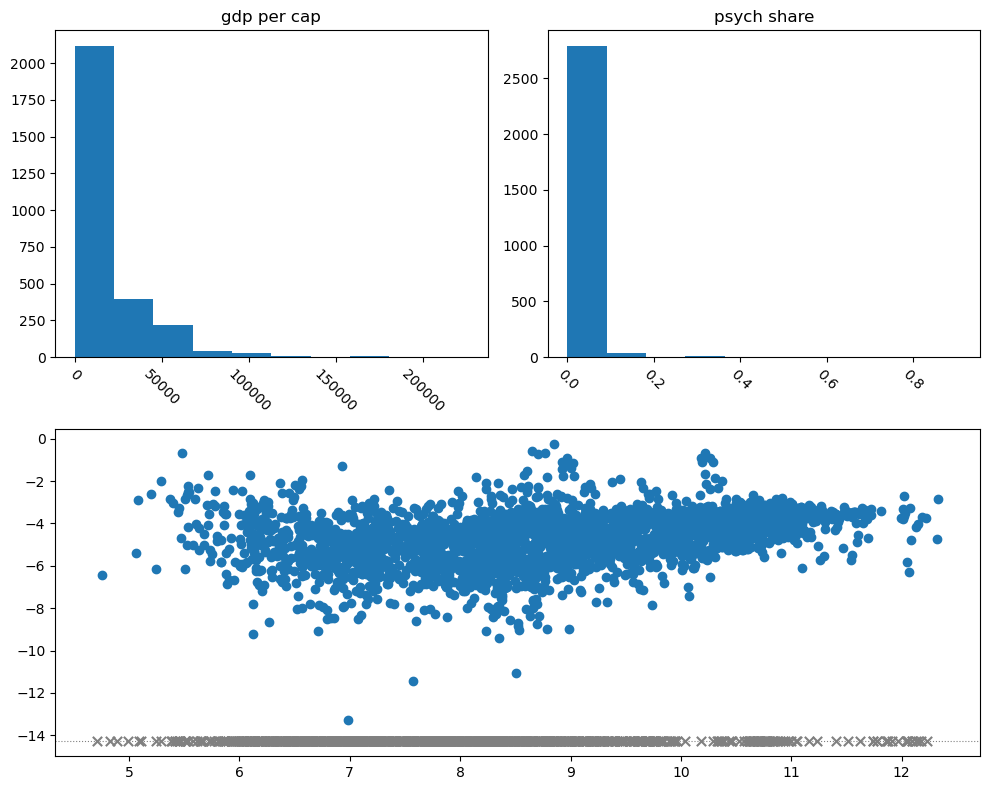

In [95]:
merged_data['psych_share'] = merged_data['Publications'] / merged_data['SE_articles_total']
merged_data_nonzero = merged_data[merged_data['Publications'] > 0]
merged_data_zeros = merged_data[merged_data['Publications'] == 0].dropna(subset=['GDP_per_capita'])

n_zero = (merged_data['Publications'] == 0).sum()
print(f"{n_zero:,} of {len(merged_data):,} country-year observations are zero "
      f"({n_zero / len(merged_data):.1%})"
      f", {len(merged_data[merged_data['Publications'] == 0]) - len(merged_data_zeros)} of which have no GDP per capita data")


fig = plt.figure(figsize=(10,8))

ax1 = plt.subplot2grid((2, 2), (0,0))
ax1.hist(merged_data_nonzero['GDP_per_capita'])
ax1.set_title('gdp per cap')

ax2 = plt.subplot2grid((2, 2), (0,1))
ax2.hist(merged_data_nonzero['psych_share'])
ax2.set_title('psych share')

ax3 = plt.subplot2grid((2, 2), (1,0), colspan=2)

x = np.asarray(np.log(merged_data_nonzero['GDP_per_capita']))
y = np.asarray(np.log(merged_data_nonzero['psych_share']))
ax3.scatter(x,y)
floor = y.min() - 1.0
ax3.scatter(np.log(merged_data_zeros['GDP_per_capita']), [floor] * len(merged_data_zeros),
            marker='x', s=45, color='gray')
ax3.axhline(floor, color='gray', lw=0.8, ls=':')
ax3.text(x.min(), floor + 0.25, f'{len(merged_data_zeros)} countries with zero psychology publications '
         '— undefined in logs', fontsize=8, color='gray')

for ax in [ax1, ax2]:
    ax.tick_params(axis='x', rotation=-45)

plt.tight_layout()

Zeros in dependent var will violate OLS so we move to PPML to handle zeros, heteroscedasticity

### PPML, year fixed effects

In [ ]:
# Compute without denominator cutoff

panel = merged_data.dropna(subset=['GDP_per_capita', 'SE_articles_total']).copy()
panel = panel[panel['SE_articles_total'] > 0].copy()

panel['log_gdp'] = np.log(panel['GDP_per_capita'])
panel['offset'] = np.log(panel['SE_articles_total'])

print(f"Panel: {len(panel)} country-years, {panel['iso_alpha'].nunique()} countries, "
      f"{panel['Year'].min()}-{panel['Year'].max()}")
print(f"Zero-publication country-years retained: {(panel['Publications'] == 0).sum()} "
      f"({(panel['Publications'] == 0).mean():.1%}) ")

balance = panel.groupby('Year').size()
print(f"Country-years per year: min {balance.min()} ({balance.idxmin()}), "
      f"max {balance.max()} ({balance.idxmax()})")

zero_by_country = panel.groupby('iso_alpha')['Publications'].apply(lambda x: (x == 0).mean())
print(zero_by_country.sort_values(ascending=False).head(20))

Panel: 3761 country-years, 193 countries, 2003-2022
Zero-publication country-years retained: 999 (26.6%) 
Country-years per year: min 185 (2005), max 190 (2009)
iso_alpha
PLW    1.000000
TLS    1.000000
STP    1.000000
DJI    1.000000
MHL    1.000000
KIR    1.000000
FSM    1.000000
GNQ    1.000000
NRU    1.000000
VUT    0.950000
TKM    0.950000
SLB    0.950000
COM    0.950000
LCA    0.950000
MDV    0.950000
TUV    0.941176
AND    0.900000
WSM    0.900000
ATG    0.900000
ERI    0.888889
Name: Publications, dtype: float64


offset test

In [19]:
year_dummies = pd.get_dummies(panel['Year'], prefix='yr', drop_first=True, dtype=float)

# Check offset restriction is near 1

Xp_unrestricted = sm.add_constant(pd.concat(
    [panel[['log_gdp', 'offset']].rename(columns={'offset': 'log_total'}), year_dummies], axis=1
))
ppml_unrestricted = sm.GLM(panel['Publications'], Xp_unrestricted, family=sm.families.Poisson()).fit(
    cov_type='cluster', cov_kwds={'groups': panel['iso_alpha']})

b = ppml_unrestricted.params['log_total']
se = ppml_unrestricted.bse['log_total']
print(f"unrestricted log_total coef: {b:.3f} (se {se:.3f})")
print(f"test coef == 1: z = {(b - 1) / se:.2f}")

# Sensitivity to year dummies

# Without year dummies
X_no_dummies = sm.add_constant(panel[['log_gdp']])
ppml_no_dummies = sm.GLM(
    panel['Publications'], X_no_dummies, family=sm.families.Poisson(), offset=panel['offset']
).fit(cov_type='cluster', cov_kwds={'groups': panel['iso_alpha']})
print("\nWithout year dummies:")
print(f"  log_gdp coef: {ppml_no_dummies.params['log_gdp']:.3f} (se {ppml_no_dummies.bse['log_gdp']:.3f})")

# With year dummies
X_with_dummies = sm.add_constant(pd.concat([panel[['log_gdp']], year_dummies], axis=1))
ppml_with_dummies = sm.GLM(
    panel['Publications'], X_with_dummies, family=sm.families.Poisson(), offset=panel['offset']
).fit(cov_type='cluster', cov_kwds={'groups': panel['iso_alpha']})

print("\nWith year dummies:")
print(f"  log_gdp coef: {ppml_with_dummies.params['log_gdp']:.3f} (se {ppml_with_dummies.bse['log_gdp']:.3f})")


unrestricted log_total coef: 1.017 (se 0.037)
test coef == 1: z = 0.45

Without year dummies:
  log_gdp coef: 1.164 (se 0.146)

With year dummies:
  log_gdp coef: 1.219 (se 0.154)


### PPML with country fixed effects: within-country vs. between-country variation

In [20]:
country_dummies = pd.get_dummies(panel['iso_alpha'], prefix='c', drop_first=True, dtype=float)

# no country FE (year FE only)
Xp = sm.add_constant(pd.concat([panel[['log_gdp']], year_dummies], axis=1))
ppml_no_fe = sm.GLM(
    panel['Publications'], Xp, family=sm.families.Poisson(), offset=panel['offset']
).fit(cov_type='cluster', cov_kwds={'groups': panel['iso_alpha']})

# with country FE
Xp_fe = sm.add_constant(pd.concat([panel[['log_gdp']], year_dummies, country_dummies], axis=1))
ppml_fe = sm.GLM(
    panel['Publications'], Xp_fe, family=sm.families.Poisson(), offset=panel['offset']
).fit(cov_type='cluster', cov_kwds={'groups': panel['iso_alpha']})

print(f"log_gdp, no country FE : {ppml_no_fe.params['log_gdp']:.3f} (se {ppml_no_fe.bse['log_gdp']:.3f})")
print(f"log_gdp, with country FE: {ppml_fe.params['log_gdp']:.3f} (se {ppml_fe.bse['log_gdp']:.3f})")

pearson_chi2 = ppml_fe.pearson_chi2
dof = ppml_fe.df_resid
print(f"Pearson chi2/df, with country FE: {pearson_chi2/dof:.2f}")

log_gdp, no country FE : 1.219 (se 0.154)
log_gdp, with country FE: 1.075 (se 0.339)
Pearson chi2/df, with country FE: 5.60


### GDP per capita x year model

In [21]:
panel['log_gdp_x_trend'] = panel['log_gdp'] * (panel['Year'] - 2011)

Xp_interact = sm.add_constant(pd.concat(
    [panel[['log_gdp', 'log_gdp_x_trend']], year_dummies, country_dummies], axis=1
))

ppml_interact = sm.GLM(
    panel['Publications'],
    Xp_interact, family=sm.families.Poisson(),
    offset=panel['offset']
).fit(
    cov_type='cluster',
    cov_kwds={'groups': panel['iso_alpha']}
)

b_main = ppml_interact.params['log_gdp']
b_trend = ppml_interact.params['log_gdp_x_trend']
se_trend = ppml_interact.bse['log_gdp_x_trend']

print(f"log_gdp (at 2011): {b_main:.3f} (se {ppml_interact.bse['log_gdp']:.3f})")
print(f"log_gdp x year trend: {b_trend:.3f} (se {se_trend:.3f})")
print(f"z-test on the trend: {b_trend / se_trend:.2f}")

for year in [2003, 2009, 2011, 2016, 2022]:
    effect = b_main + b_trend * (year - 2011)
    pct = (2**effect - 1) * 100
    print(f"implied log_gdp effect in {year}: {effect:.3f} ({pct:.0f}% more psych output per GDP doubling)")

log_gdp (at 2011): 0.819 (se 0.219)
log_gdp x year trend: -0.028 (se 0.007)
z-test on the trend: -3.94
implied log_gdp effect in 2003: 1.045 (106% more psych output per GDP doubling)
implied log_gdp effect in 2009: 0.875 (83% more psych output per GDP doubling)
implied log_gdp effect in 2011: 0.819 (76% more psych output per GDP doubling)
implied log_gdp effect in 2016: 0.677 (60% more psych output per GDP doubling)
implied log_gdp effect in 2022: 0.508 (42% more psych output per GDP doubling)


In [97]:
pearson_chi2_int = ppml_interact.pearson_chi2
dof_int = ppml_interact.df_resid
print(f"Pearson chi2/df: {pearson_chi2_int/dof_int:.2f}")

print("Overdispersion (~6x), but use cluster-robust standard errors to account for variance and within-group correlation")

Pearson chi2/df: 5.92
Overdispersion (~6x), but use cluster-robust standard errors to account for variance and within-group correlation


In [23]:
print(ppml_fe.converged, ppml_interact.converged)

True True


Generate `docs/chart-data.js` for `docs/index.html`.

In [24]:
write_chart_data({"c1": map_fig, "c2": rank_fig, "c3": trend_fig})

wrote ../docs/chart-data.js (35,281 bytes)
